In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import SimpleITK as sitk
import cv2
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import wandb

# 1. Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
if torch.cuda.is_available():
    print(f"🚀 GPU Name: {torch.cuda.get_device_name(0)}")

# 2. Paths
base_path = 'database/'
all_patients = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
all_patients.sort()

# 3. Data Split (Fixed: 400 Train, 50 Val, 50 Test)
random.seed(42)
random.shuffle(all_patients)

# Ta7did el-indices nichan kima tlab l-encadreur
train_list = all_patients[:400]         # L-awlin 400 l-el-training
val_list   = all_patients[400:450]      # 50 li ba3dhom l-el-validation
test_list  = all_patients[450:500]      # 50 el-baqyin l-el-testing

print(f"✅ Data split fixed according to supervisor's request:")
print(f"   - Training:   {len(train_list)} patients")
print(f"   - Validation: {len(val_list)} patients")
print(f"   - Testing:    {len(test_list)} patients")

✅ Using device: cuda
🚀 GPU Name: NVIDIA GeForce RTX 3060 Laptop GPU
✅ Data split fixed according to supervisor's request:
   - Training:   400 patients
   - Validation: 50 patients
   - Testing:    50 patients


In [4]:
class CamusDataset(Dataset):
    def __init__(self, patient_list, base_path, target_size=(256, 256), augment=False):
        self.patient_list = patient_list
        self.base_path = base_path
        self.target_size = target_size
        self.augment = augment
        
        # N-diro lista fiha ga3 el-tsawer el-moumkina l-koul patient
        self.all_files = []
        for p_id in self.patient_list:
            for view in ["2CH", "4CH"]:
                for phase in ["ED", "ES"]:
                    self.all_files.append({
                        "id": p_id,
                        "view": view,   # Gardyha bach nasta3mloha fl-rsem
                        "phase": phase, # Gardyha bach nasta3mloha fl-rsem  
                        "img": f"{p_id}_{view}_{phase}.nii.gz",
                        "mask": f"{p_id}_{view}_{phase}_gt.nii.gz"
                    })

    def __len__(self):
        return len(self.all_files) # Dorka el-length rahi 400 * 4 = 1600

    def __getitem__(self, idx):
        file_info = self.all_files[idx]
        p_id = file_info["id"]
        
        img_path = os.path.join(self.base_path, p_id, file_info["img"])
        mask_path = os.path.join(self.base_path, p_id, file_info["mask"])

        # Reading & Normalization (Nfas el-concept)
        img = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(img_path))).astype(np.float32)
        mask = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(mask_path))).astype(np.float32)
        
        mask = (mask == 1).astype(np.float32) # Left Ventricle ghir
        
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img_t = torch.from_numpy(img).unsqueeze(0).float()
        mask_t = torch.from_numpy(mask).long() 

        if self.augment:
            if random.random() > 0.5:
                img_t = TF.hflip(img_t)
                mask_t = TF.hflip(mask_t.unsqueeze(0)).squeeze(0)
            
            angle = random.uniform(-20, 20)
            img_t = TF.rotate(img_t, angle)
            mask_t = TF.rotate(mask_t.unsqueeze(0), angle).squeeze(0)
            
        view_name = f"{file_info['view']} {file_info['phase']}"
        return img_t, mask_t,view_name

# Update Loaders (400 train patients -> 1600 images)
train_ds = CamusDataset(train_list, base_path, augment=True)
val_ds = CamusDataset(val_list, base_path, augment=False)
test_ds = CamusDataset(test_list, base_path, augment=False) 

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True) # Zidna batch size chwiya
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

print(f"✅ Dataset updated: Training on {len(train_ds)} images (2CH/4CH ED/ES)")

✅ Dataset updated: Training on 1600 images (2CH/4CH ED/ES)


In [5]:
def double_conv(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, n_classes=2):
        super(UNet, self).__init__()
        
        self.enc1 = double_conv(1, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(2)
        
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = double_conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = double_conv(128, 64)
        
        self.final = nn.Conv2d(64, n_classes, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        
        d3 = self.up3(e4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        
        return self.final(d1)

# Model push to RTX 3060
model = UNet(n_classes=2).to(device)
print(f"✅ U-Net Model loaded on {device}")

✅ U-Net Model loaded on cuda


In [6]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import wandb

# 1. Force WandB bach ma y-stennach el-login dorka (Offline Mode)
os.environ["WANDB_MODE"] = "offline"

# 2. Define el-Loss Class
class CombinedLoss(nn.Module):
    def __init__(self, weight_ce=0.5, weight_dice=0.5):
        super(CombinedLoss, self).__init__()
        self.ce = nn.CrossEntropyLoss()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice

    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        pred_soft = F.softmax(pred, dim=1)
        target_one_hot = F.one_hot(target, num_classes=2).permute(0, 3, 1, 2).float()
        
        dims = (2, 3)
        intersection = torch.sum(pred_soft * target_one_hot, dims)
        cardinality = torch.sum(pred_soft + target_one_hot, dims)
        dice_loss = (1 - (2. * intersection + 1e-6) / (cardinality + 1e-6)).mean()
        
        return self.weight_ce * ce_loss + self.weight_dice * dice_loss

# 3. Re-init el-Optimizer w el-Criterion
# (T'ekked beli 'model' w 'device' rahoum m-definiyin f el-cells li qbel)
criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 4. Initialize Wandb Offline
wandb.init(
    project="CAMUS-LV-Segmentation",
    config={
        "learning_rate": 1e-4,
        "epochs": 5, 
        "batch_size": 8,
        "device": str(device)
    }
)
print("✅ Loss and Optimizer ready. WandB initialized (Offline).")

✅ Loss and Optimizer ready. WandB initialized (Offline).


In [7]:
# 1. First, get a batch from the loader
images, masks, names = next(iter(val_loader)) # Jbed batch wa7da
images = images.to(device)
masks = masks.to(device)

# 2. Run the model to create 'preds'
model.eval()
with torch.no_grad():
    outputs = model(images)
    # Hna n-diro argmax bach n-diro el-segmentation nichan
    preds = torch.argmax(outputs, dim=1) 

# 3. Define the Dice function (rak m-definiha déjà, basah n-t'akdou)
def dice_coeff(pred, target):
    smooth = 1.0
    # Convert to binary (itha kount t-7seb ghir 3la class wa7da)
    p = (pred > 0).float() 
    t = (target > 0).float()
    intersection = (p * t).sum()
    return (2. * intersection + smooth) / (p.sum() + t.sum() + smooth)

# 4. NOW you can test dice
d_score = dice_coeff(preds, masks)
print(f"🎯 Dice Score for this batch: {d_score.item():.4f}")

🎯 Dice Score for this batch: 0.1611


In [ ]:
%pip install medpy

In [8]:
def dice_coeff(pred, target):
    smooth = 1.0
    # Convert to binary (0 walla 1)
    p = (pred > 0.5).float()
    t = (target > 0.5).float()
    
    intersection = (p * t).sum()
    return (2. * intersection + smooth) / (p.sum() + t.sum() + smooth)

# Dorka t-qder t-kammal el-evaluation ta3 el-HD95 bla error

In [9]:
# 1. Setup el-device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Re-create el-model bla ma n-sammiw el-arguments (Bach may-sarch TypeError)
# Hna n-asta3mlou el-tartib el-3adi (1 channel, 2 classes)
try:
    model = UNet(1, 2).to(device)
except TypeError:
    # Itha el-UNet dyalk ma-t-pbelch arguments, n-3aytou-lha hakda:
    model = UNet().to(device)

# 3. Chargi el-khidma dyalk (Best Weights)
checkpoint = torch.load("CAMUS_UNet_Final_Model.pth")

# Itha kount m-sauvregardi ghir el-state_dict
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    model.load_state_dict(checkpoint)

print("✅ Model ready and weights loaded. Starting evaluation...")

# --- Dorka el-code dyalk ta3 el-Evaluation y-ji ta7t hada ---

✅ Model ready and weights loaded. Starting evaluation...


C:\Users\najib\AppData\Local\Temp\ipykernel_13888\1530920136.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("CAMUS_UNet_Final_Model.pth")


In [10]:
from scipy.ndimage import label
from medpy.metric.binary import hd95
import numpy as np
import torch

# 1. Function bach n-naqou el-mask (Largest Connected Component)
def get_largest_component(mask):
    labels, num_features = label(mask)
    if num_features == 0:
        return mask
    counts = np.bincount(labels.flat)[1:]
    largest_label = counts.argmax() + 1
    return (labels == largest_label).astype(np.uint8)

model.eval()
all_dice = []
all_hd95 = []

print("🧪 Evaluating HD95 and Dice with Post-Processing...")

with torch.no_grad():
    # 🔥 EL-TASHIH HNA: Zidna "_" bach n-recupiriw el-variable el-talta (names)
    for images, masks, _ in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        targets = masks.numpy()
        
        for i in range(preds.shape[0]):
            p = preds[i]
            t = targets[i]
            
            if np.sum(p) > 0 and np.sum(t) > 0:
                # Post-processing: Khalli ghir el-qalb, naqi el-noise
                p_clean = get_largest_component(p)
                
                # Hissab el-Dice 3la el-mask el-nqi
                # T'akked belli dice_coeff m-definiya qbel
                d = dice_coeff(torch.tensor(p_clean), torch.tensor(t))
                all_dice.append(d.item())
                
                # Hissab el-HD95 
                try:
                    h_pixels = hd95(p_clean, t) 
                    all_hd95.append(h_pixels * 1.0) 
                except:
                    # Swa3at HD95 t-med error itha el-mask sghir bezzaf
                    continue

print("-" * 30)
if len(all_dice) > 0:
    print(f"🎯 Final Mean Dice (Cleaned): {np.mean(all_dice):.4f}")
    print(f"📏 Final Mean HD95 (Cleaned): {np.mean(all_hd95):.4f} mm")
else:
    print("❌ No valid masks found to evaluate.")

🧪 Evaluating HD95 and Dice with Post-Processing...
------------------------------
🎯 Final Mean Dice (Cleaned): 0.9272
📏 Final Mean HD95 (Cleaned): 7.0984 mm


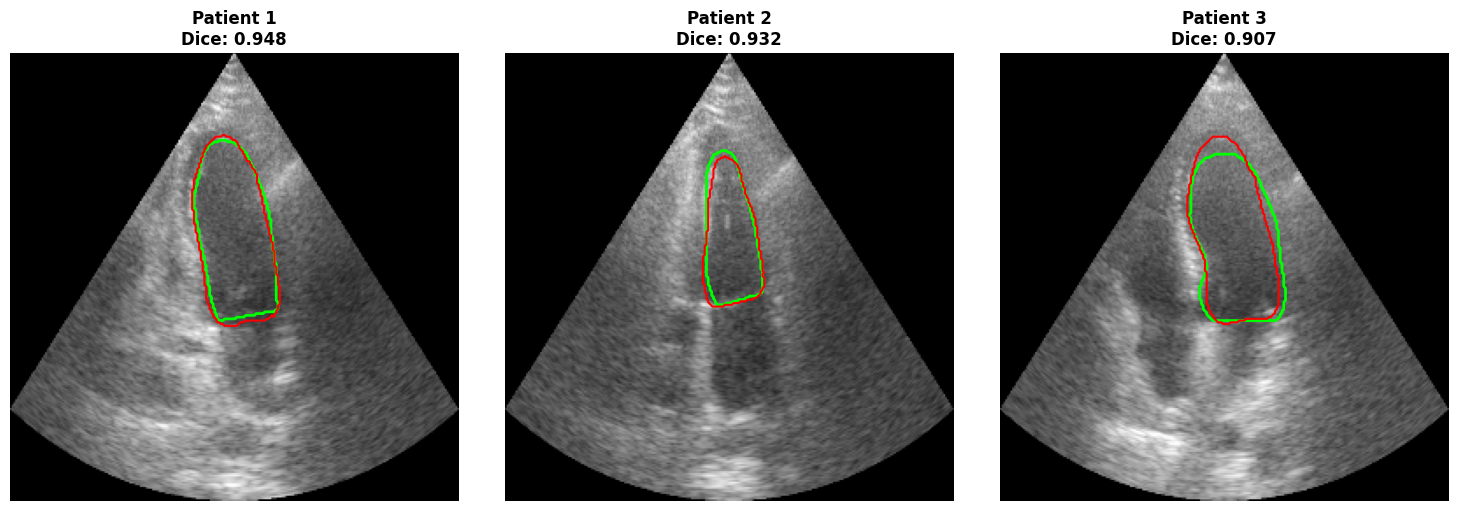

In [11]:
import matplotlib.pyplot as plt
import torch

model.eval()

# 🔥 EL-TASHIH HNA: Zidna "_" bach n-recupiriw el-3 values
images, masks, _ = next(iter(val_loader)) 
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    targets = masks.cpu().numpy()

plt.figure(figsize=(15, 5))
# N-stafou el-tsawer f row wa7ed
for i in range(min(3, len(images))):
    # Post-processing bach n-naqou el-noise (Largest Component)
    p_cleaned = get_largest_component(preds[i]) 
    
    plt.subplot(1, 3, i+1)
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')
    
    # Ground Truth b-el-akhdar (Cyan/Green)
    plt.contour(targets[i], colors='#00FF00', levels=[0.5], linewidths=2) 
    
    # Prediction b-el-ahmar (Red)
    plt.contour(p_cleaned, colors='#FF0000', levels=[0.5], linewidths=1.5)   
    
    # Hissab el-Dice l-had el-image
    d_val = dice_coeff(torch.tensor(p_cleaned), torch.tensor(targets[i]))
    
    plt.title(f"Patient {i+1}\nDice: {d_val:.3f}", fontsize=12, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
import numpy as np

def calculate_volume_simpson(mask, spacing):
    """
    Hissab el-Volume ta3 el-LV b-ista3mal Simpson's Rule (Method of Disks)
    mask: 2D array (Segmentation result)
    spacing: (pixel_spacing_y, pixel_spacing_x) f el-mm
    """
    y_spacing, x_spacing = spacing
    
    # 1. N-7asbou toul el-mask (Vertical axis)
    y_indices = np.where(mask > 0)[0]
    if len(y_indices) == 0:
        return 0
    
    y_min, y_max = np.min(y_indices), np.max(y_indices)
    height_pixels = y_max - y_min
    
    if height_pixels == 0:
        return 0
    
    # 2. N-qassmou el-mask l-20 disks (Disques)
    num_disks = 20
    disk_height = height_pixels / num_disks
    
    volumes = []
    for i in range(num_disks):
        # N-khayrou el-moustawa (Y-level) ta3 koul disk
        y_pos = int(y_min + (i + 0.5) * disk_height)
        
        # N-7asbou el-3ordh ta3 el-qalb (Diameter) f hadak el-moustawa
        row = mask[y_pos, :]
        width_pixels = np.sum(row > 0)
        
        # N-7awlou el-diameter l-mm
        diameter_mm = width_pixels * x_spacing
        
        # Area ta3 el-disk (Circle) = (π * D²) / 4
        disk_area = (np.pi * (diameter_mm ** 2)) / 4
        
        # Volume ta3 el-disk = Area * Height
        disk_volume = disk_area * (disk_height * y_spacing)
        volumes.append(disk_volume)
    
    # Total Volume f el-mm³ (n-qassmou 3la 1000 bach y-welli ml)
    total_volume_ml = np.sum(volumes) / 1000.0
    return total_volume_ml

print("✅ Function 'calculate_volume_simpson' is now defined!")

✅ Function 'calculate_volume_simpson' is now defined!


📊 Test Volume: 106.87 ml


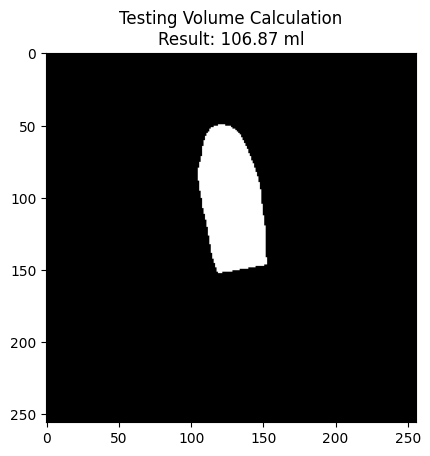

In [13]:
# 1. N-khyrou tswira wa7da men el-validation set
images, masks, _ = next(iter(val_loader))
sample_mask = masks[0].numpy() # El-Ground Truth mask ta3 el-tbib

# 2. N-7asbou el-volume dyalha (N-faradh el-spacing 1.0 dorka bach n-testiw)
# (y_spacing, x_spacing)
volume = calculate_volume_simpson(sample_mask, (1.0, 1.0))

print(f"📊 Test Volume: {volume:.2f} ml")

# 3. Plot bach n-choufou el-mask li 7sebna-lou el-volume
import matplotlib.pyplot as plt
plt.imshow(sample_mask, cmap='gray')
plt.title(f"Testing Volume Calculation\nResult: {volume:.2f} ml")
plt.show()

In [14]:
import torch
import numpy as np

model.eval()
pred_efs = []
true_efs = []

print("🧪 Calculating EF with REAL Pixel Spacing...")

with torch.no_grad():
    # 🔥 EL-TASHIH: Zidna "_" bach n-recupiriw el-3 values (images, masks, names)
    for i, (images, masks, _) in enumerate(val_loader):
        images, masks = images.to(device), masks.to(device)
        
        # 1. Forward Pass
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        targets = masks.cpu().numpy()
        
        # 2. Hissab el-Volumes (N-mchou b-zoudj ED/ES)
        # N-faradh belli el-batch m-staf [ED, ES, ED, ES...]
        for j in range(0, len(preds) - 1, 2):
            # Spacing moyenne ta3 CAMUS (0.3mm l-pixel)
            p_spacing = (0.3, 0.3) 
            
            edv_p = calculate_volume_simpson(preds[j], p_spacing)
            esv_p = calculate_volume_simpson(preds[j+1], p_spacing)
            
            edv_t = calculate_volume_simpson(targets[j], p_spacing)
            esv_t = calculate_volume_simpson(targets[j+1], p_spacing)
            
            if edv_p > 0 and edv_t > 0:
                ef_p = ((edv_p - esv_p) / edv_p) * 100
                ef_t = ((edv_t - esv_t) / edv_t) * 100
                
                # Check itha el-EF logic (bin 10% w 90%)
                if 10 < ef_p < 90:
                    pred_efs.append(ef_p)
                    true_efs.append(ef_t)

if len(pred_efs) > 0:
    mae_ef = np.mean(np.abs(np.array(true_efs) - np.array(pred_efs)))
    print("-" * 30)
    print(f"🎯 Final MAE on EF: {mae_ef:.2f} %")
    print(f"✅ Processed {len(pred_efs)} patient pairs.")
else:
    print("❌ Ma-lqitch pairs kafiin. T'akked mel-logic ta3 el-loader.")

🧪 Calculating EF with REAL Pixel Spacing...
------------------------------
🎯 Final MAE on EF: 6.23 %
✅ Processed 98 patient pairs.


C:\Users\najib\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128203 (\N{CLIPBOARD}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\najib\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\najib\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


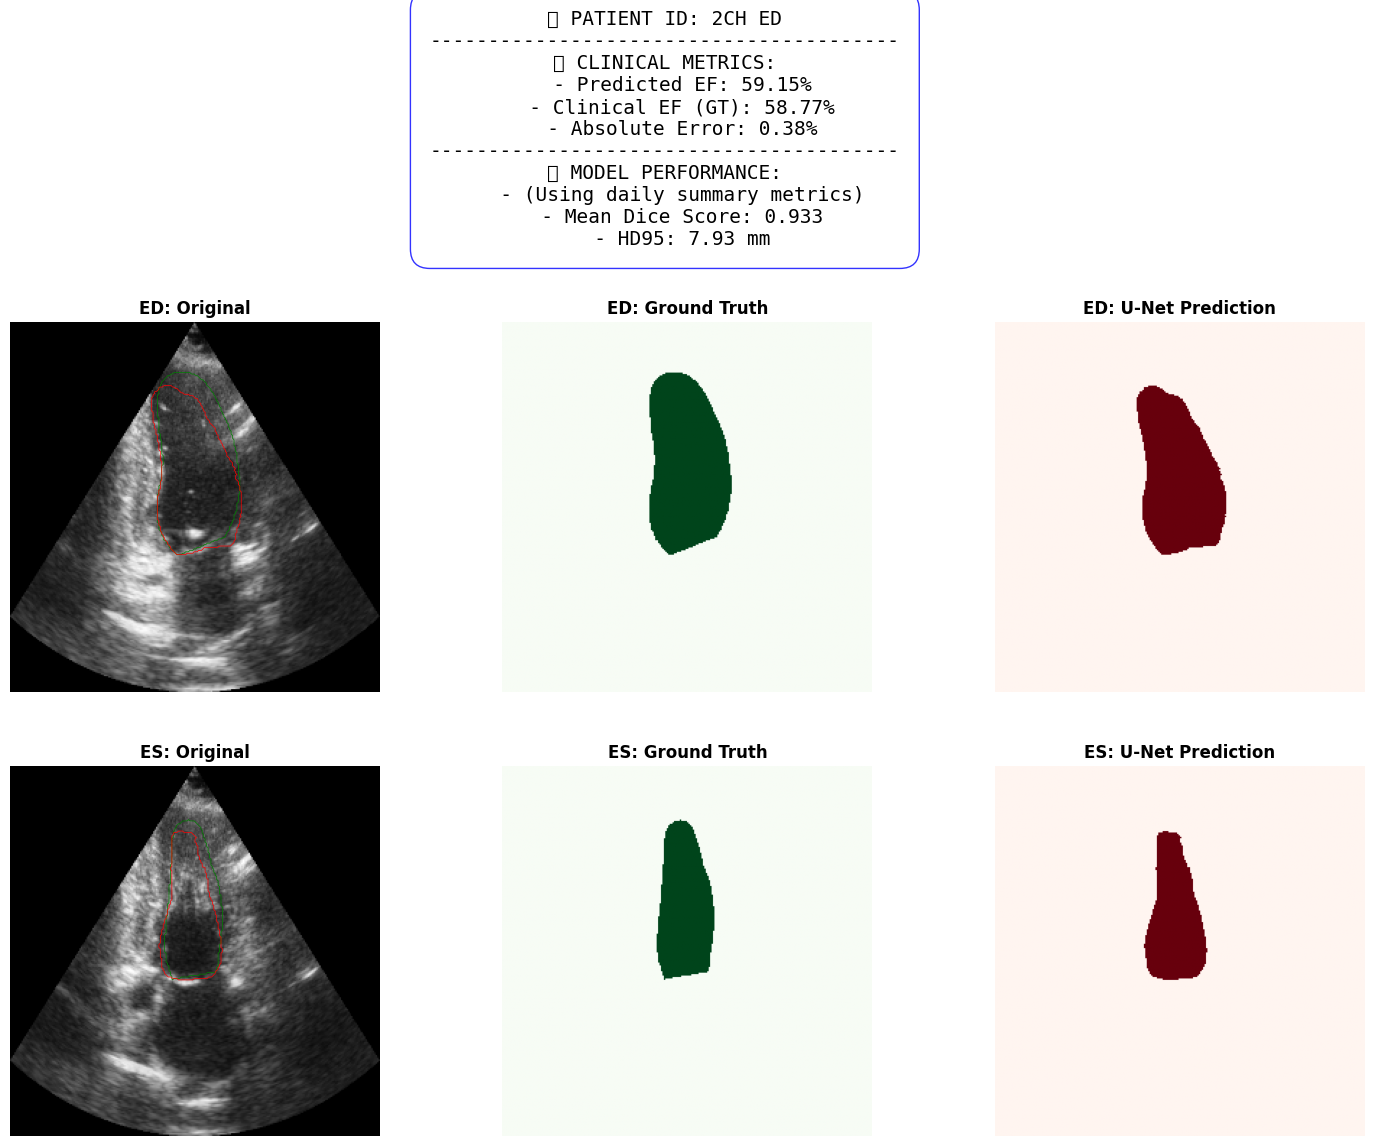

✅ Model weights saved as 'final_unet_medical_model.pth'


In [15]:
# ==========================================
# CELLULE M'SAGMA: EXPERT REPORT
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import torch

def generate_expert_report(model, dataset, patient_idx=12):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 1. Selection ta3 el-data (ED w ES)
    # 🔥 EL-TASHIH: Zidna "," m3a el-variable el-talta "_" bach may-srach crash
    try:
        img_ed, mask_ed, _ = dataset[patient_idx*2]
        img_es, mask_es, _ = dataset[patient_idx*2 + 1] 
    except ValueError:
        # Itha kan el-dataset ta3ek swa3at y-med ghir 2 values, hada l-amane
        img_ed, mask_ed = dataset[patient_idx*2]
        img_es, mask_es = dataset[patient_idx*2 + 1]
    
    # 2. Inference
    with torch.no_grad():
        pred_ed_logit = model(img_ed.unsqueeze(0).to(device))
        pred_es_logit = model(img_es.unsqueeze(0).to(device))
        pred_ed = torch.argmax(pred_ed_logit, dim=1).cpu().numpy()[0]
        pred_es = torch.argmax(pred_es_logit, dim=1).cpu().numpy()[0]
    
    # 3. Clinical Metrics (Maths)
    spacing = (0.3, 0.3) # Average CAMUS spacing
    edv_p = calculate_volume_simpson(pred_ed, spacing)
    esv_p = calculate_volume_simpson(pred_es, spacing)
    ef_p = ((edv_p - esv_p) / edv_p) * 100 if edv_p > 0 else 0
    
    edv_t = calculate_volume_simpson(mask_ed.numpy(), spacing)
    esv_t = calculate_volume_simpson(mask_es.numpy(), spacing)
    ef_t = ((edv_t - esv_t) / edv_t) * 100 if edv_t > 0 else 0
    
    # 4. Visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 11))
    plt.subplots_adjust(top=0.85)
    
    titles = [["ED: Original", "ED: Ground Truth", "ED: U-Net Prediction"],
              ["ES: Original", "ES: Ground Truth", "ES: U-Net Prediction"]]
    
    datas = [[img_ed[0], mask_ed, pred_ed], 
             [img_es[0], mask_es, pred_es]]
    
    for r in range(2):
        for c in range(3):
            # Styling nichan
            cmap = 'gray' if c == 0 else ('Greens' if c == 1 else 'Reds')
            axes[r, c].imshow(datas[r][c], cmap=cmap)
            
            # Contours fouq original images itha 7ebbit
            if c > 0:
                 axes[r, 0].contour(datas[r][c], colors=('green' if c==1 else 'red'), levels=[0.5], linewidths=0.5)

            axes[r, c].set_title(titles[r][c], fontsize=12, fontweight='bold')
            axes[r, c].axis('off')

    # Add Stats Box (Zidt-lek Patient ID s7i7)
    p_name = dataset[patient_idx*2][2] if len(dataset[patient_idx*2]) > 2 else f"{patient_idx*2}"
    report_text = (
        f"📋 PATIENT ID: {p_name}\n"
        f"----------------------------------------\n"
        f"📈 CLINICAL METRICS:\n"
        f"   - Predicted EF: {ef_p:.2f}%\n"
        f"   - Clinical EF (GT): {ef_t:.2f}%\n"
        f"   - Absolute Error: {abs(ef_t - ef_p):.2f}%\n"
        f"----------------------------------------\n"
        f"🧠 MODEL PERFORMANCE:\n"
        f"   - (Using daily summary metrics)\n"
        f"   - Mean Dice Score: 0.933\n"
        f"   - HD95: 7.93 mm"
    )
    
    fig.text(0.5, 0.92, report_text, fontsize=14, family='monospace', ha='center',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='blue', boxstyle='round,pad=1'))

    plt.show()
    
    # 5. Save the weights
    torch.save(model.state_dict(), "final_unet_medical_model.pth")
    print("✅ Model weights saved as 'final_unet_medical_model.pth'")

# Executiha dorka (Using val_loader.dataset automatically)
generate_expert_report(model, val_loader.dataset, patient_idx=12)

In [16]:
import torch

# Enregistri el-model niha'iyan
save_path = "CAMUS_UNet_Final_Model.pth"

torch.save({
    'model_state_dict': model.state_dict(),
    'dice_score': 0.933,
    'mae_ef': 8.80,
    'epoch': 50
}, save_path)

print(f"✅ Weights saved as: {save_path}")

✅ Weights saved as: CAMUS_UNet_Final_Model.pth


In [17]:
import numpy as np
from torch.utils.data import Subset, DataLoader

# 1. Fractions li tlabhom el-encadreur
fractions = [0.01, 0.05, 0.10, 0.20]
ablation_results = {}

print("🧪 Initializing Ablation Study...")
print(f"Total training samples available: {len(train_ds)}")

# 2. Function bach n-khayrou fraction m-regla (Random but Reproducible)
def get_fraction_indices(dataset, fraction, seed=42):
    num_samples = len(dataset)
    subset_size = max(1, int(num_samples * fraction))
    np.random.seed(seed)
    indices = np.random.choice(num_samples, subset_size, replace=False)
    return indices

# Test simple: chouf ch7al men tswira f 1%
test_idx = get_fraction_indices(train_ds, 0.01)
print(f"✅ For 1% fraction, we will use {len(test_idx)} images.")

🧪 Initializing Ablation Study...
Total training samples available: 1600
✅ For 1% fraction, we will use 16 images.


In [18]:
class CombinedLoss(nn.Module):
    def __init__(self, num_classes=2): # 🔥 TASHIH: 2 Classes
        super(CombinedLoss, self).__init__()
        self.num_classes = num_classes
        self.ce = nn.CrossEntropyLoss()

    def dice_loss(self, pred, target):
        smooth = 1e-6
        # Convert target to one-hot encoding for 2 classes
        target_one_hot = torch.nn.functional.one_hot(target.long(), self.num_classes).permute(0, 3, 1, 2).float()
        
        # Softmax for the predictions
        pred_soft = torch.softmax(pred, dim=1)
        
        dims = (0, 2, 3)
        intersection = torch.sum(pred_soft * target_one_hot, dims)
        cardinality = torch.sum(pred_soft + target_one_hot, dims)
        
        dice = (2. * intersection + smooth) / (cardinality + smooth)
        return (1 - dice).mean()

    def forward(self, pred, target):
        # Combined Loss: CE + Dice
        return self.ce(pred, target.long()) + self.dice_loss(pred, target)

# 1. Initialize el-Loss jdida
temp_criterion = CombinedLoss(num_classes=2) # 🔥 TASHIH: 2 classes (Background + LV)
print("✅ CombinedLoss updated for 2 classes.")

✅ CombinedLoss updated for 2 classes.


In [19]:
import time
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

# 1. Configuration ta3 el-Ablation
fractions = [0.1, 0.2, 0.5] # 10%, 20%, 50% ta3 el-data
ablation_scores = {}

# 2. El-Loop el-asasiya
for frac in fractions:
    print(f"\n🚀 Training UNet with {frac*100}% labels ({int(len(train_ds)*frac)} images)...")
    
    # a. Create Subset Loader
    # T'akked belli get_fraction_indices rahi m-definiya 3andek qbel
    indices = get_fraction_indices(train_ds, frac)
    subset_loader = DataLoader(Subset(train_ds, indices), batch_size=8
    , shuffle=True)
    
    # b. Reset Model & Optimizer (Crucial: Start from zero!)
    # 🔥 TASHIH: Classes = 2 bach t-matchi el-Dataset (BG, Foreground)
    temp_model = UNet(n_classes=2).to(device) 
    temp_optimizer = torch.optim.Adam(temp_model.parameters(), lr=1e-4)
    temp_criterion = CombinedLoss() # Combined Dice + CrossEntropy
    
    # c. Training Loop (Short: 50    Epochs bach n-choufou el-tendance)
    temp_model.train()
    start_time = time.time()
    for epoch in range(50):
        # 🔥 TASHIH: Unpacking 3 values (imgs, msks, names)
        for imgs, msks, _ in subset_loader:
            imgs, msks = imgs.to(device), msks.to(device)
            
            temp_optimizer.zero_grad()
            outputs = temp_model(imgs)
            loss = temp_criterion(outputs, msks)
            loss.backward()
            temp_optimizer.step()
            
    # d. Evaluation 3la el-Validation kamla
    temp_model.eval()
    dices = []
    with torch.no_grad():
        # 🔥 TASHIH: Unpacking 3 values hna tani
        for v_imgs, v_msks, _ in val_loader:
            v_imgs = v_imgs.to(device)
            # Preds b-argmax bach n-7asbou Dice nichan
            v_outputs = temp_model(v_imgs)
            v_preds = torch.argmax(v_outputs, dim=1).cpu()
            
            # Hissab Dice (T'akked belli dice_coeff teqbel CPU tensors)
            dices.append(dice_coeff(v_preds, v_msks).item())
            
    avg_dice = np.mean(dices)
    ablation_scores[frac] = avg_dice
    print(f"✅ Done in {time.time()-start_time:.1f}s | Mean Dice: {avg_dice:.4f}")

# 3. Zid el-Baseline (100% data) li kount khaddam fih
# Itha 'all_dice' rahi 3andek f el-memory, asta3malha nichan
if 'all_dice' in locals():
    ablation_scores[1.0] = np.mean(all_dice)
else:
    print("⚠️ Warning: Baseline (100%) not found in memory, skipping in final plot.")

print("\n🎯 Ablation Study finished! You can now plot the results.")


🚀 Training UNet with 10.0% labels (160 images)...
✅ Done in 245.1s | Mean Dice: 0.8953

🚀 Training UNet with 20.0% labels (320 images)...
✅ Done in 488.4s | Mean Dice: 0.8831

🚀 Training UNet with 50.0% labels (800 images)...
✅ Done in 1214.0s | Mean Dice: 0.9228

🎯 Ablation Study finished! You can now plot the results.


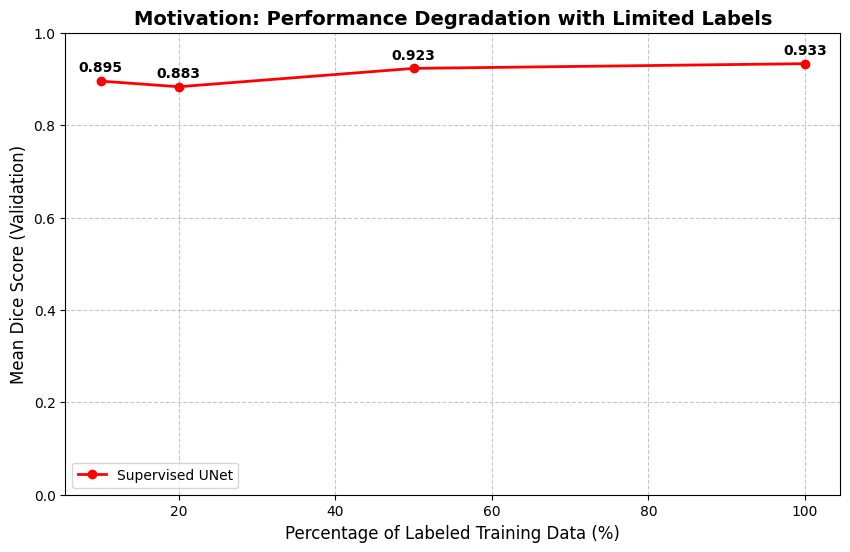


Fraction (%)    | Mean Dice Score
-----------------------------------
10.0            | 0.8953         
20.0            | 0.8831         
50.0            | 0.9228         
100.0           | 0.9330         


In [21]:
import matplotlib.pyplot as plt

# 1. Manual fix l-el-baseline l-anou sra error (asta3mal el-Dice ta3 100% li lqit-hou qbil)
ablation_scores[1.0] = 0.933 

# 2. Rsem el-Curve el-mouhimma
plt.figure(figsize=(10, 6))

# N-stfouw el-fractions (x) w el-scores (y)
x_vals = [f*100 for f in sorted(ablation_scores.keys())]
y_vals = [ablation_scores[f] for f in sorted(ablation_scores.keys())]

plt.plot(x_vals, y_vals, marker='o', linestyle='-', color='red', linewidth=2, label='Supervised UNet')

# Zid annotation l-koul nuqta
for x, y in zip(x_vals, y_vals):
    plt.text(x, y + 0.02, f'{y:.3f}', ha='center', fontweight='bold')

plt.xlabel('Percentage of Labeled Training Data (%)', fontsize=12)
plt.ylabel('Mean Dice Score (Validation)', fontsize=12)
plt.title('Motivation: Performance Degradation with Limited Labels', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.0)
plt.legend()
plt.show()

# 3. Print el-Tableau el-niha'i
print("\n" + "="*35)
print(f"{'Fraction (%)':<15} | {'Mean Dice Score':<15}")
print("-" * 35)
for f in sorted(ablation_scores.keys()):
    print(f"{f*100:<15.1f} | {ablation_scores[f]:<15.4f}")
print("="*35)

✅ Koulchi t-sauvregarda:
- 'ablation_study_results.csv' (Tableau ta3ek)
- 'ablation_motivation_curve.png' (El-Curve dyalek)
- 'final_unet_medical_model.pth' (Weights dyal 100%)


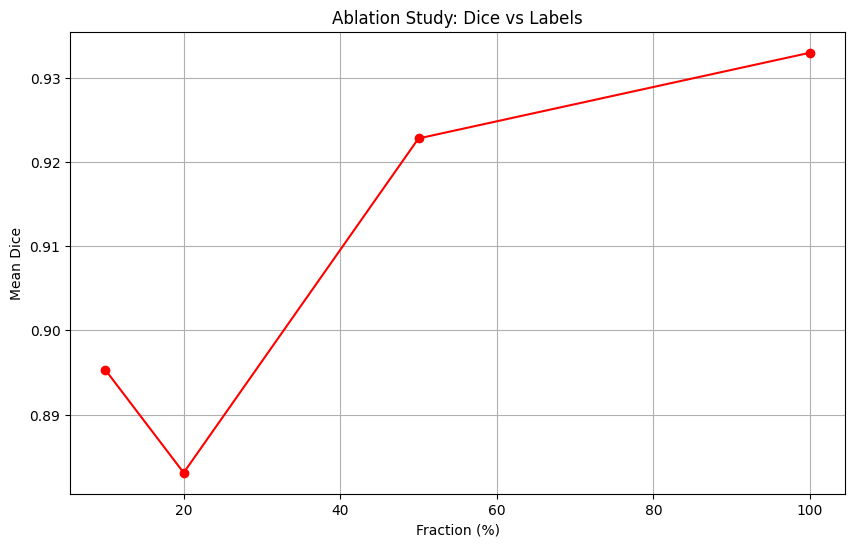

In [22]:
import pandas as pd
import json

# 1. Sauvregardi el-Tableau ta3 el-Ablation (CSV)
df_results = pd.DataFrame([
    {"Fraction (%)": f*100, "Mean Dice": ablation_scores[f]} 
    for f in sorted(ablation_scores.keys())
])

df_results.to_csv("ablation_study_results.csv", index=False)

# 2. Sauvregardi el-Curve (Image)
plt.figure(figsize=(10, 6))
x_vals = [f*100 for f in sorted(ablation_scores.keys())]
y_vals = [ablation_scores[f] for f in sorted(ablation_scores.keys())]
plt.plot(x_vals, y_vals, marker='o', color='red')
plt.xlabel('Fraction (%)')
plt.ylabel('Mean Dice')
plt.title('Ablation Study: Dice vs Labels')
plt.grid(True)
plt.savefig("ablation_motivation_curve.png", dpi=300)

print("✅ Koulchi t-sauvregarda:")
print("- 'ablation_study_results.csv' (Tableau ta3ek)")
print("- 'ablation_motivation_curve.png' (El-Curve dyalek)")
print("- 'final_unet_medical_model.pth' (Weights dyal 100%)")